# Week 2: Loan Prediction - Feature Engineering and Data preprocessing

## 1. Import Libraries

In [213]:
import pandas as pd   #load the pandas library into the Python notebook

import matplotlib.pyplot as plt #importing the matplotlib.pyplot into the Python noteblook for visualisations

import seaborn as sns          #importing Seaoborn library into the Python notebook

## 2. Load Dataset

In [214]:
df=pd.read_csv("train_u6lujuX_CVtuZ9i.csv")      #we want pandas to read our csv file and store/load it in a data frame(df)

## 3. Data Inspection

### 3.1 Display first 10 rows

In [215]:
df.head(10)   #we checking if it loaded our data correctly by displaying first 10 rows

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


### 3.2 Dataset structure

In [216]:
df.shape        #Checking the structure of the dataset

(614, 13)

#### The dataset contains 614 rows and 13 columns. Each row represents a loan application, while the columns contain information about the applicant and loan application.

### 3.3 Rows and columns

In [217]:
df.columns   #checking the actual column names 

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

#### The variables include applicant demographic and financial information, loan characteristics, credit history, property area, and the loan approval outcome.

### 3.4 Data types

In [218]:
df.dtypes    #We want to know the data type in each column 

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

#### The dataset contains both categorical and numerical variables. Categorical variables are stored as strings (str), while numerical variables are stored as integers (int64) or floating point values (float64).

### 3.5 Missing values

In [219]:
df.isnull().sum()  #We are checking for missing values in each cell and count how many are there in each column

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

#### Seven variables contain missing observations: Gender (13), Married (3), Dependents (15), Self_Employed (32), LoanAmount (22), Loan_Amount_Term (14), and Credit_History (50). 

### 3.6 Duplicate records

In [220]:
df.duplicated().sum()  #We are checking the duplicate rows and the number of them in the dataset

np.int64(0)

#### The duplicate record check identified 0 duplicate rows in the dataset. Therefore, we can confirm that al 614 records are unique based on the complete set of variables.

### 3.7 Numerical summary statistics

In [221]:
df.describe()     #We want to understand the numerical variables in the dateset                

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


#### The dataset contains five numerical variables. ApplicantIncome has a mean of 5,403.46 and ranges from 150 to 81,000, while LoanAmount ranges from 9 to 700. The count values also confirm missing observations in LoanAmount, Loan_Amount_Term, and Credit_History.

### 3.8 Categorical summary Statistics

In [222]:
df.describe(include="str")   #We want to understand the categorical variables in the dateset                     

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP001002,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


#### The dataset contains variables with between two and four unique categories, excluding Loan_ID, which is a unique identifier. The most frequent categories include Male for Gender, Yes for Married, 0 for Dependents, Graduate for Education, No for Self_Employed, Semiurban for Property_Area, and Y for Loan_Status. The count values also confirm the presence of missing observations in Gender, Married, Dependents, and Self_Employed.

## 4. Exploratory Data Analysis (EDA)

### 4.1 Target variable distribution

In [223]:
df["Loan_Status"].value_counts()  #We calculating the actual counts, meaning how many times each value appears in the Loan_Status column

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [224]:
df["Loan_Status"].value_counts(normalize=True)*100 #Calculating the percentage of each class

Loan_Status
Y    68.729642
N    31.270358
Name: proportion, dtype: float64

#### The target variable (Loan_Status) contains 422 approved loan applications (68.73%) and 192 non-approved applications (31.27%). This shows that approved applications are more common than non-approved applications in the dataset. 

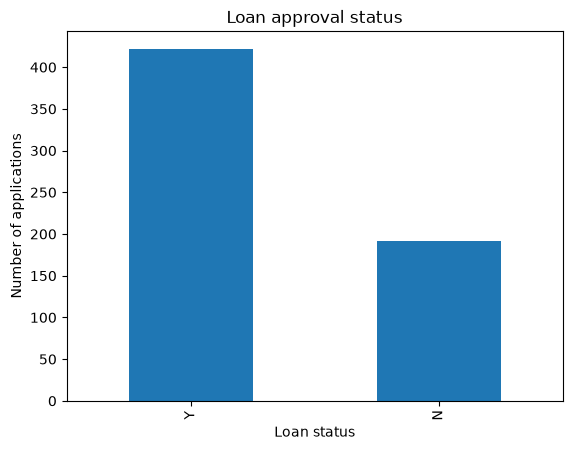

In [225]:
df["Loan_Status"].value_counts().plot(kind="bar") #drawing a bar graph, labelling the title, x and y axis, and displaying it

plt.title("Loan approval status")  

plt.xlabel("Loan status")

plt.ylabel("Number of applications")

plt.show()

### Interpretation

The graph is showing that loan approvals (Y) are more frequent than loan rejections (N). There are 422 approved applications compared with 192 applications that were not approved. This indicates that the target variable is not evenly distributed across the two classes.

### 4.2 Loan approval by gender

In [226]:
pd.crosstab(df["Gender"],df["Loan_Status"]) #creating a cross-tabulation to compare gender and Loan_Status as we want to know if the loan approval differes based on gender

pd.crosstab(df["Gender"],df["Loan_Status"],normalize="index")*100  #Calculating percentage approval by gender

Loan_Status,N,Y
Gender,,
Female,33.035714,66.964286
Male,30.674847,69.325153


### Interpretation

The cross-tabulation shows that 66.96% of female applicants and 69.33% of male applicants had their loans approved. The approval rate was therefore slightly higher among male applicants, with a difference of approximately 2.37 percentage points.

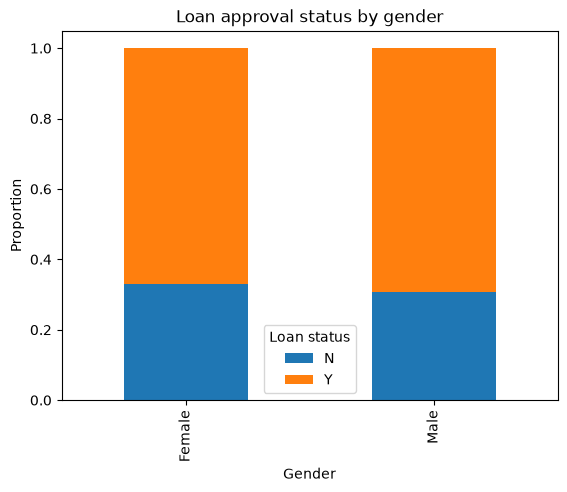

In [227]:
pd.crosstab(df["Gender"],df["Loan_Status"],normalize="index").plot(kind="bar", stacked=True)   #Drawing a stacked bar graph because we want to see the proportion of approved and non-approved applications within each gender

plt.title("Loan approval status by gender")       #labelling the title,x and y axis, legent title and displaying the graph

plt.xlabel("Gender")

plt.ylabel("Proportion")

plt.legend(title="Loan status")

plt.show()

### Interpretation

The graph shows that 66.96% of female applicants and 69.33% of male applicants had their loans approved. The approval rate was therefore slightly higher among male applicants, with a difference of approximately 2.37 percentage points.

### 4.3 Loan approval by education

In [228]:
pd.crosstab(df["Education"],df["Loan_Status"])    #creating a cross-tabulation to compare education and Loan_Status as we want to know if the loan approval differes based on education

pd.crosstab(df["Education"],df["Loan_Status"],normalize="index")*100 #Calculating percentage approval by education

Loan_Status,N,Y
Education,,
Graduate,29.166667,70.833333
Not Graduate,38.805970,61.194030


### Interpretation

The cross-tabulation results show that 70.83% of graduate applicants had their loans approved, compared with 61.19% of applicants who were not graduates. This represents an approval rate difference of approximately 9.64 percentage points.

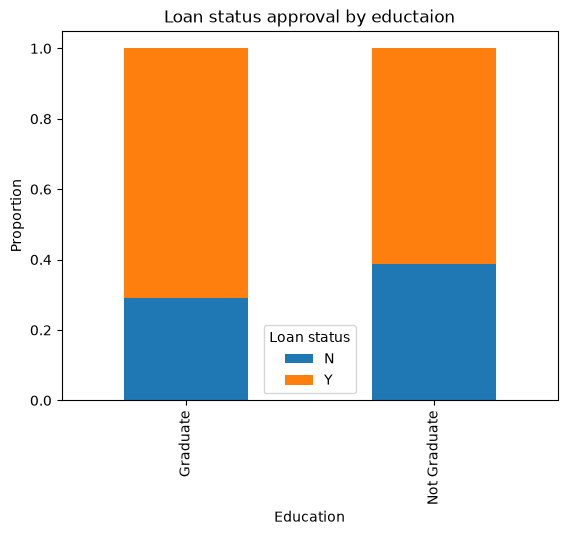

In [229]:
pd.crosstab(df["Education"],df["Loan_Status"],normalize="index").plot(kind="bar", stacked=True)     #Drawing a stacked bar graph because we want to see the proportion of approved and non-approved applications based on their education level 

plt.title("Loan status approval by eductaion")          #labelling the title,x and y axis, legent title and displaying the graph

plt.xlabel("Education")

plt.ylabel("Proportion")

plt.legend(title="Loan status")

plt.show()

### Interpretation

The graph shows that graduate applicants had a higher loan approval rate than non-graduate applicants. Approximately 70.83% of graduate applicants had their loans approved, compared with 61.19% of non-graduate applicants. This represents a difference of about 9.64 percentage points.

### 4.4 Distribution of applicant income

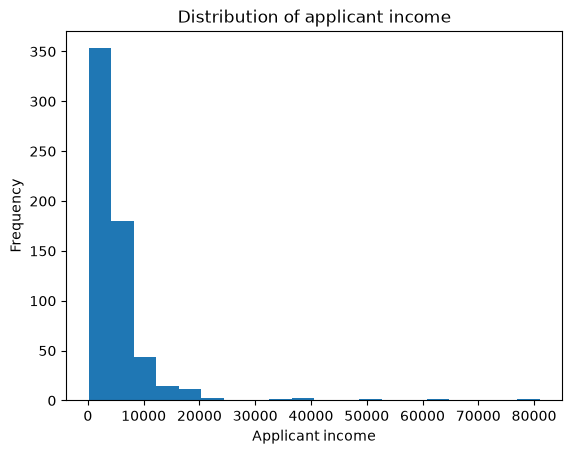

In [230]:
df["ApplicantIncome"].plot(kind="hist", bins=20)   #drawing a histogram graph to investigate the distribution of ApplicantIncome

plt.title("Distribution of applicant income")      #labelling the title,x and y axis,and displaying the graph

plt.xlabel("Applicant income")

plt.ylabel("Frequency")

plt.show()

### Interpretation

The graph shows that ApplicantIncome is concentrated mainly at the lower income levels, while fewer applicants have higher incomes. The distribution is right-skewed, with a long tail extending toward higher income values. This indicates that a small number of applicants have substantially higher incomes than most applicants in our dataset.

### 4.5 Distribution of loan amount

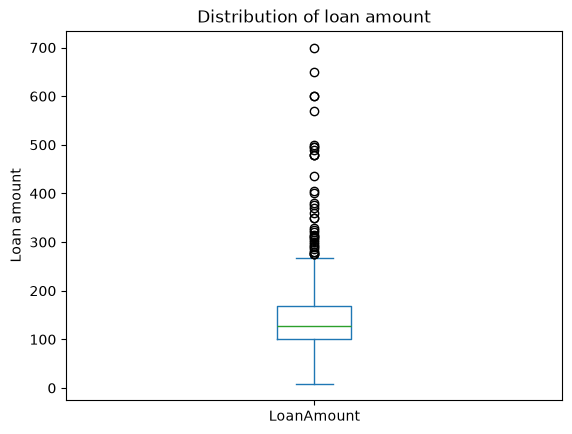

In [231]:
df["LoanAmount"].plot(kind="box")   #drawing a boxplot graph to investigate whether there are unusually high or low loan amounts.

plt.title("Distribution of loan amount")   #labelling the title,y axis,and displaying the graph


plt.ylabel("Loan amount")

plt.show()


### Interpretation

The box plot shows the distribution and spread of LoanAmount values in the dataset. The median loan amount is approximately 128, while most loan amounts are concentrated within the middle range of the distribution. The plot also shows several values beyond the upper whisker, indicating potential high value outliers. 

### 4.6 Correlation between numerical variables

In [232]:
df[["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]].corr()  #Creating the correlation table

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
ApplicantIncome,1.000000,-0.116605,0.570909,-0.045306,-0.014715
CoapplicantIncome,-0.116605,1.000000,0.188619,-0.059878,-0.002056
LoanAmount,0.570909,0.188619,1.000000,0.039447,-0.008433
Loan_Amount_Term,-0.045306,-0.059878,0.039447,1.000000,0.001470
Credit_History,-0.014715,-0.002056,-0.008433,0.001470,1.000000


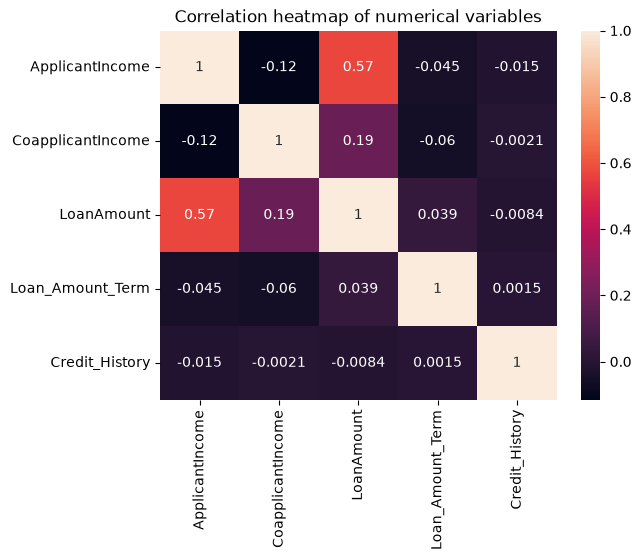

In [233]:
correlation=df[["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "Loan_Amount_Term", "Credit_History"]].corr() #store the correlation table in a variable called correlation

sns.heatmap(correlation, annot=True)   #turn the correlation table into a heatmap and write the actual correlation values inside each cell

plt.title("Correlation heatmap of numerical variables")     #labelling the title and displaying the graph

plt.show()

### Interpretation

The correlation heatmap shows the strength and direction of the linear relationships between the numerical variables in our dataset. The strongest relationship is between ApplicantIncome and LoanAmount, with a correlation coefficient of 0.57, indicating a moderate positive relationship. This suggests that applicants with higher incomes tend to have higher loan amounts. CoapplicantIncome and LoanAmount show a weak positive relationship (0.19), while the remaining variables have correlations close to zero, indicating very weak linear relationships. 

### 4.7 Applicant income vs loan amount

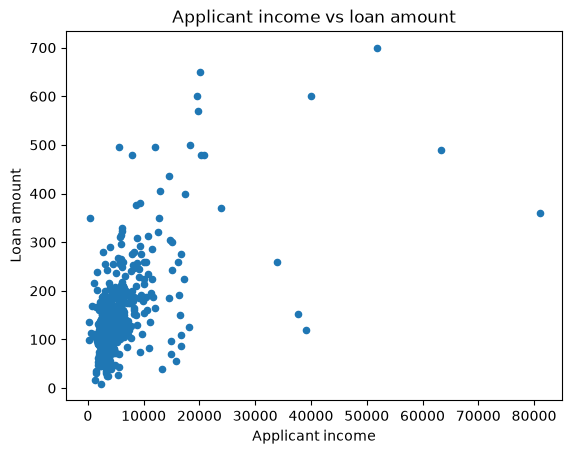

In [234]:
df.plot(kind="scatter", x="ApplicantIncome", y="LoanAmount")  #Drawing the scatter plot graph to vissually examine the relationship between applicant income and Loan amount

plt.title("Applicant income vs loan amount")                  #labelling the title,x and y axis,and displaying the graph

plt.xlabel("Applicant income")

plt.ylabel("Loan amount")

plt.show()

## 5. Data preprocessing

### 5.1 Handling missing values

In [235]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [236]:
df[["Gender", "Married", "Dependents","Self_Employed"]].describe(include="str") #we want to see what values exist in the categorial columns

,Gender,Married,Dependents,Self_Employed
count,601,611,599,582
unique,2,2,4,2
top,Male,Yes,0,No
freq,489,398,345,500


### Interpretation

The categorical variables contain some missing values. The most frequent categories are Male for Gender, Yes for Married, 0 for Dependents, and No for Self_Employed. Since these variables are categorical, the mode can be used to replace their missing values. This approach preserves the existing categories without introducing new values.

In [237]:
df["Credit_History"].value_counts(dropna=False)  #examining the credit history since it was stored as flot164, we want to count and include missing values as well

Credit_History
1.0    475
0.0     89
NaN     50
Name: count, dtype: int64

In [238]:
df["Gender"]=df["Gender"].fillna(df["Gender"].mode()[0]) #Replace missing gender values with the most common gender
df["Gender"].isnull().sum()

np.int64(0)

### Interpretation

The missing values in the Gender variable were replaced using the mode, which was Male. After imputation, the Gender variable contains no missing values.

In [239]:
df["Married"]=df["Married"].fillna(df["Married"].mode()[0])  #Replace missing married values with the most common married value
df["Married"].isnull().sum()

np.int64(0)

### Interpretation

The missing values in the Married variable were replaced using the mode, which was Yes. After imputation, the Married variable contains no missing values.

In [240]:
df["Dependents"]=df["Dependents"].fillna(df["Dependents"].mode()[0])  #Replace missing dependents values with the most common dependents value
df["Dependents"].isnull().sum()

np.int64(0)

### Interpretation

The missing values in the Dependents variable were replaced using the mode, which was 0. After imputation, the Dependents variable contains no missing values.

In [241]:
df["Self_Employed"]=df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])  #Replace missing self employed values with the most common self employed value
df["Self_Employed"].isnull().sum()

np.int64(0)

### Interpretation

The missing values in the Self_Employed variable were replaced using the mode, which was No. After imputation, the Self_Employed variable contains no missing values.

In [242]:
df["Credit_History"]=df["Credit_History"].fillna(df["Credit_History"].mode()[0])  #Replace missing credit history values with the most common credit history value
df["Credit_History"].isnull().sum()

np.int64(0)

### Interpretation

The missing values in the Credit_History variable were replaced using the mode, which was 1.0. After imputation, the Credit_History variable contains no missing values.

In [243]:
df["LoanAmount"].describe()    #Checking the statistics again

count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

In [244]:
df["LoanAmount"]=df["LoanAmount"].fillna(df["LoanAmount"].median()) #Replace missing loan amount values with the median value
df["LoanAmount"].isnull().sum()

np.int64(0)

### Interpretation

The missing values in the LoanAmount variable were replaced using the median value of 128. The median was selected because it is less affected by extreme values than the mean. After imputation, the LoanAmount variable contains no missing values.

In [245]:
df["Loan_Amount_Term"].describe()  #Checking the statistics again

count    600.00000
mean     342.00000
std       65.12041
min       12.00000
25%      360.00000
50%      360.00000
75%      360.00000
max      480.00000
Name: Loan_Amount_Term, dtype: float64

In [246]:
df["Loan_Amount_Term"]=df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].median()) #Replace missing loan amount term values with the median value

df["Loan_Amount_Term"].isnull().sum()

np.int64(0)

### Interpretation

The missing values in the Loan_Amount_Term variable were replaced using the median value of 360. The median was selected because most observations are concentrated around 360, while some unusually low values could influence the mean. After imputation, the Loan_Amount_Term variable contains no missing values.

### 5.2 Final check for missing values

In [247]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

### Interpretation

The final check confirms that all missing values have been successfully handled. All 13 variables now contain zero missing values. Categorical variables were imputed using their mode, while numerical variables were imputed using their median where appropriate. The dataset is therefore complete with respect to missing value handling and is ready for the next preprocessing step.

### 5.3 Checking for duplicate records

In [248]:
df.duplicated().sum()

np.int64(0)

### Interpretation

The duplicate check returned zero, indicating that there are no duplicate records in the dataset. Therefore, no rows need to be removed due to duplication, and all 614 records can be retained for the next stages of data preprocessing.

### 5.4 Checking data types

In [249]:
df.dtypes

Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

### Interpretation

The data types were checked to ensure that the variables are appropriately represented for further preprocessing. The categorical variables are stored as string (str) data types, while the numerical variables are stored as integer (int64) or floating point (float64) data types. Credit_History is stored as a float64 variable, although it represents a binary categorical feature with values of 0 and 1. Overall, the data types are suitable for the next stages of preprocessing.

### 5.5 Removing irrelevant features

Loan_ID is an identifier assigned to each loan application and does not provide meaningful information for predicting loan approval. Therefore, it will be removed from the dataset before the machine-learning stage.

In [250]:
df=df.drop("Loan_ID",axis=1)

In [251]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

### Interpretation

The Loan_ID feature has been successfully removed because it is only an identifier and does not provide meaningful information for predicting loan approval. The dataset now contains 12 relevant variables for further preprocessing and analysis.

### 5.6 Encoding categorical variables

Machine-learning algorithms generally require numerical inputs. Therefore, the categorical variables will be converted into numerical representations. Before encoding, the unique categories in each categorical variable are examined to determine the appropriate encoding approach.

In [252]:
categorical_columns=["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area", "Loan_Status"]             #Creating a list of our categorical columns,then go through each column one by one and print the different categories found in that column

for column in categorical_columns:     #For loop (go through each column name stored in catergorical_columns)

    print(column, ":", df[column].unique())  #display the results in a a readable format

Gender : <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
Married : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Dependents : <ArrowStringArray>
['0', '1', '2', '3+']
Length: 4, dtype: str
Education : <ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
Self_Employed : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
Property_Area : <ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str
Loan_Status : <ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str


### Interpretation

The categorical variables and their unique categories were examined before encoding. Gender, Married, Education, Self_Employed, and Loan_Status each contain two categories, while Dependents contains four categories and Property_Area contains three categories. Loan_Status is the target variable, while the remaining categorical variables are features that will be used for prediction.

### 5.6.1 Separating features and target Variable

The Loan_Status variable is the target variable that the model will predict. The remaining variables will be used as features to provide information for predicting loan approval.

In [253]:
x=df.drop("Loan_Status", axis=1)   #take all the columns expect the loan status
y=df["Loan_Status"]                #Select only the loan status

In [254]:
x.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban


In [255]:
y.head()

0    Y
1    N
2    Y
3    Y
4    Y
Name: Loan_Status, dtype: str

### Interpretation

The dataset was successfully separated into features (x) and the target variable (y). The feature dataset contains the applicant and loan related variables used to make predictions, while the Loan_Status variable was separated as the target to be predicted.

### 5.6.2 Encoding categorical features

The categorical features in the dataset were converted into numerical form using one-hot encoding. The pd.get_dummies() function was used to create binary indicator columns for the categorical variables. This allows the categorical information to be represented numerically without imposing an artificial numerical order on the categories.

In [256]:
x=pd.get_dummies(x, drop_first=True)  #Convert the categorical columns in x into dummy/indicator variables

In [257]:
x.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True


### Interpretation

The categorical features were successfully converted into binary indicator variables using one-hot encoding. The drop_first=True option was used to remove one category from each categorical variable and avoid redundant information. The resulting feature dataset now contains numerical and Boolean variables that can be used by machine-learning algorithms.

In [258]:
x.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='str')

### Interpretation

After one-hot encoding, the categorical features were successfully transformed into binary indicator variables. The original categorical columns were replaced by numerical/Boolean features, resulting in 14 predictor variables. The drop_first=True option removed one category from each categorical variable to avoid redundant information.

### 5.6.3 Encoding the target variable

In [259]:
y=y.map({"Y":1, "N":0})    #find the Y and N in the loan status and replace them with 1 and 0

In [260]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: Loan_Status, dtype: int64

### Interpretation

The target variable, Loan_Status, was successfully converted from categorical values into numerical values. Loan approvals represented by Y were encoded as 1, while loan rejections represented by N were encoded as 0. This numerical representation makes the target variable suitable for machine-learning algorithms.

In [261]:
y.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

### Interpretation

The encoded target variable contains 422 approved loan applications and 192 rejected loan applications. This corresponds to approximately 68.73% approved applications and 31.27% rejected applications. The target classes are therefore somewhat imbalanced, with approved applications representing the majority class.

## 5.7 Outlier detection and handling

Outliers were investigated in the numerical variables to identify observations that differ substantially from the majority of the data. The Interquartile Range (IQR) method was selected because it is a simple and robust technique for identifying unusually high or low values.

The IQR method uses the first quartile (Q1) and third quartile (Q3) to determine the range containing the middle 50% of the observations. Values that fall below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered potential outliers.

The variables examined were ApplicantIncome, CoapplicantIncome, LoanAmount, and Loan_Amount_Term.

In [262]:
numeric_features=["ApplicantIncome","CoapplicantIncome", "LoanAmount", "Loan_Amount_Term"]  #selecting numerical variables we want to examine for outliers


### 5.7.1 Calculating the Interquartile Range (IQR)

The first quartile (Q1), third quartile (Q3), and Interquartile Range (IQR) were calculated for each numerical variable. Q1 represents the 25th percentile, while Q3 represents the 75th percentile. The IQR represents the middle 50% of the observations and is calculated as Q3 minus Q1.

In [263]:
for column in numeric_features:     #for loop: go through each of our four numerical variables one at a time
                                    
    Q1= df[column].quantile(0.25)   #Then, find the 25th percentile
    Q3= df[column].quantile(0.75)   #Then, find the 75th percentile
    
    IQR= Q3-Q1                       #determine IQR by subtracting Q3 from Q1

    print(column)                   #displaying the results so we can examine them
    print("Q1:",Q1)
    print("Q3:",Q3)
    print("IQR:",IQR)
    print()
  

ApplicantIncome
Q1: 2877.5
Q3: 5795.0
IQR: 2917.5

CoapplicantIncome
Q1: 0.0
Q3: 2297.25
IQR: 2297.25

LoanAmount
Q1: 100.25
Q3: 164.75
IQR: 64.5

Loan_Amount_Term
Q1: 360.0
Q3: 360.0
IQR: 0.0



### 5.7.2 Identifying Potential Outliers

The lower and upper boundaries for potential outliers were calculated using the 1.5 × IQR rule. Observations below the lower boundary or above the upper boundary were classified as potential outliers. The number of observations falling outside these boundaries was then determined for each numerical variable.

In [264]:
for column in numeric_features:     #for loop: go through each of our four numerical variables one at a time
                                    
    Q1= df["Loan_Amount_Term"].quantile(0.25)   #Then, find the 25th percentile
    Q3= df["Loan_Amount_Term"].quantile(0.75)   #Then, find the 75th percentile
    
    IQR= Q3-Q1                       #determine IQR by subtracting Q3 from Q1
    
lower_bound=Q1 - 1.5*IQR            #Calculating the lower and upper bounds
upper_bound=Q3 + 1.5*IQR

outliers=(df["Loan_Amount_Term"]<lower_bound) | (df["Loan_Amount_Term"]>upper_bound)   #We want to know if the value is below the lower boundary or above the upper boundary

len(outliers)     #Counting how many observations meet that condition

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower boundary:",lower_bound)
print("Upper boundary:",upper_bound)
print("Number of potential outliers:",outliers.sum())

Q1: 360.0
Q3: 360.0
IQR: 0.0
Lower boundary: 360.0
Upper boundary: 360.0
Number of potential outliers: 88


In [265]:
for column in numeric_features:     #for loop: go through each of our four numerical variables one at a time
                                    
    Q1= df["ApplicantIncome"].quantile(0.25)   #Then, find the 25th percentile
    Q3= df["ApplicantIncome"].quantile(0.75)   #Then, find the 75th percentile
    
    IQR= Q3-Q1                       #determine IQR by subtracting Q3 from Q1
    
lower_bound=Q1 - 1.5*IQR            #Calculating the lower and upper bounds
upper_bound=Q3 + 1.5*IQR

outliers=(df["ApplicantIncome"]<lower_bound) | (df["ApplicantIncome"]>upper_bound)   #We want to know if the value is below the lower boundary or above the upper boundary

len(outliers)     #Counting how many observations meet that condition

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower boundary:",lower_bound)
print("Upper boundary:",upper_bound)
print("Number of potential outliers:",outliers.sum())



Q1: 2877.5
Q3: 5795.0
IQR: 2917.5
Lower boundary: -1498.75
Upper boundary: 10171.25
Number of potential outliers: 50


In [266]:
for column in numeric_features:     #for loop: go through each of our four numerical variables one at a time
                                    
    Q1= df["CoapplicantIncome"].quantile(0.25)   #Then, find the 25th percentile
    Q3= df["CoapplicantIncome"].quantile(0.75)   #Then, find the 75th percentile
    
    IQR= Q3-Q1                       #determine IQR by subtracting Q3 from Q1
    
lower_bound=Q1 - 1.5*IQR            #Calculating the lower and upper bounds
upper_bound=Q3 + 1.5*IQR

outliers=(df["CoapplicantIncome"]<lower_bound) | (df["CoapplicantIncome"]>upper_bound)   #We want to know if the value is below the lower boundary or above the upper boundary

len(outliers)     #Counting how many observations meet that condition

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower boundary:",lower_bound)
print("Upper boundary:",upper_bound)
print("Number of potential outliers:",outliers.sum())

Q1: 0.0
Q3: 2297.25
IQR: 2297.25
Lower boundary: -3445.875
Upper boundary: 5743.125
Number of potential outliers: 18


In [267]:
for column in numeric_features:     #for loop: go through each of our four numerical variables one at a time
                                    
    Q1= df["LoanAmount"].quantile(0.25)   #Then, find the 25th percentile
    Q3= df["LoanAmount"].quantile(0.75)   #Then, find the 75th percentile
    
    IQR= Q3-Q1                       #determine IQR by subtracting Q3 from Q1
    
lower_bound=Q1 - 1.5*IQR            #Calculating the lower and upper bounds
upper_bound=Q3 + 1.5*IQR

outliers=(df["LoanAmount"]<lower_bound) | (df["LoanAmount"]>upper_bound)   #We want to know if the value is below the lower boundary or above the upper boundary

len(outliers)     #Counting how many observations meet that condition

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower boundary:",lower_bound)
print("Upper boundary:",upper_bound)
print("Number of potential outliers:",outliers.sum())

Q1: 100.25
Q3: 164.75
IQR: 64.5
Lower boundary: 3.5
Upper boundary: 261.5
Number of potential outliers: 41


In [268]:
df["Loan_Amount_Term"].value_counts().sort_index()  #counts how many times each loan term occurs and arranges the terms from smallest to largest

Loan_Amount_Term
12.0       1
36.0       2
60.0       2
84.0       4
120.0      3
180.0     44
240.0      4
300.0     13
360.0    526
480.0     15
Name: count, dtype: int64

### 5.7.3 Outlier handling decision

The IQR method identified 50 potential outliers in ApplicantIncome, 18 in CoapplicantIncome, and 41 in LoanAmount. These observations were not automatically removed because extreme income or loan values may represent legitimate applicants rather than data entry errors.

For Loan_Amount_Term, the IQR method identified 88 potential outliers because the first and third quartiles were both 360 months, resulting in an IQR of zero. Further inspection showed that the dataset contains several valid loan term values, including 12, 36, 60, 84, 120, 180, 240, 300, 360, and 480 months. Therefore, these observations were retained rather than treated as erroneous outliers.

Overall, the identified outliers were retained because there was no sufficient evidence that they represented incorrect data. This approach preserves potentially meaningful information and avoids unnecessarily reducing the size of the dataset.

### 5.8 Splitting the dataset into training and testing sets

The dataset was divided into training and testing sets to evaluate the model's ability to make predictions on unseen data. An 80/20 split was used, with 80% of the data allocated for training and 20% reserved for testing.

In [269]:
from sklearn.model_selection import train_test_split    #importing the train_test_split from sklearn (Scikit-learn), a Python library commonly used for machine learning

In [270]:
x_train, x_test, y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=42)

###### print("Training features:", x_train.shape)
print("Testing features:", x_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

### Interpretation

The dataset was successfully divided into training and testing sets using an 80/20 split. The training set contains 491 observations and 14 features, while the testing set contains 123 observations and the same 14 features. The training data will be used to develop the predictive model, while the testing data will be used to evaluate its performance on unseen observations.

In [271]:
print("Training target distribution:")       #Displaying a heading in the output and count how many 1 and 0 are there in the y_train
print(y_train.value_counts())

print("\nTesting target distribution:")       #(\n)starting on a new line, Displaying a heading in the output and count how many 1 and 0 are there in the y_test
print(y_test.value_counts())

Training target distribution:
Loan_Status
1    342
0    149
Name: count, dtype: int64

Testing target distribution:
Loan_Status
1    80
0    43
Name: count, dtype: int64


### Interpretation

The target distribution was examined in both the training and testing sets. The training set contains 342 approved and 149 rejected loan applications, while the testing set contains 80 approved and 43 rejected applications. Both datasets contain observations from both target classes, allowing the model to learn and be evaluated on both loan approval outcomes.

### 5.9 Feature scaling

Feature scaling is applied to numerical variables with different ranges to ensure that variables with larger numerical values do not disproportionately influence the model. The continuous numerical features will be standardized, while binary features will remain unchanged.

In [272]:
from sklearn.preprocessing import StandardScaler   #importing StandardScaler, Scikit-learn tool that standardizes numerical features 

In [273]:
numeric_features=["ApplicantIncome","CoapplicantIncome", "LoanAmount","Loan_Amount_Term"]  #Creating list containing the four continuous numerical features we want to scale

In [274]:
scaler = StandardScaler () #Creating our scaling tool

In [275]:
x_train[numeric_features] = scaler.fit_transform(x_train[numeric_features])  #Scaling the training data

In [276]:
x_train[numeric_features].head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
83,0.083915,0.180667,1.355734,0.287611
90,-0.429338,0.385430,-0.197609,0.287611
227,0.126095,0.005831,0.718168,0.287611
482,-0.576970,0.464185,-0.232385,0.287611
464,-0.225522,-0.528127,-0.580149,0.287611


### Interpretation

The continuous numerical features were successfully standardized using StandardScaler. The original values were transformed to a common scale based on the mean and standard deviation of the training data. This scaling helps ensure that variables with larger numerical ranges do not disproportionately influence the machine-learning model.

In [277]:
x_test[numeric_features].head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term
350,9083,0.0,228.0,360.0
377,4310,0.0,130.0,360.0
163,4167,1447.0,158.0,360.0
609,2900,0.0,71.0,360.0
132,2718,0.0,70.0,360.0


### Interpretation

The numerical features in the testing dataset were successfully standardized using the scaling parameters obtained from the training dataset. The same transformation was applied to the testing data without fitting the scaler again, preventing data leakage. The features are now prepared for model development.

## 6. Feature selection


### 6.1 Feature importance analysis

Feature importance analysis was performed to identify the variables that contribute most to predicting loan approval status. A Random Forest classifier was used because it can capture relationships between multiple features and provides a feature importance score for each predictor.

The feature importance scores will be used to rank the predictors and support decisions about which features should be retained in the final machine-learning dataset.

In [278]:
from sklearn.ensemble import RandomForestClassifier #import randomforestclassifier, machine-learning algorithm that combines many decision trees to make predictions

In [279]:
rf_model= RandomForestClassifier(n_estimators=100, random_state=42)  #Creating our Random Forest machine-learning model which uses 100 decision trees and ensures we get the same results when we run the code again, making our analysis reproducible

rf_model.fit(x_train,y_train) #Training the model using x_train and y_train data

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### 6.2 Feature importance scores

The feature importance scores generated by the Random Forest model were extracted to determine the relative contribution of each predictor to the prediction of loan approval status. Higher importance scores indicate features that contributed more to the model's decision-making process.

In [280]:
feature_importance=pd.DataFrame({"Feature": x_train.columns, "Importance": rf_model.feature_importances_})   #Creates a table with two columns (Feature → the name of each predictor, Importance → the importance score assigned by Random Forest model)

feature_importance = feature_importance.sort_values(by= "Importance", ascending=False)  #Arranges the features from most important to least important
feature_importance

,Feature,Importance
4,Credit_History,0.237788
0,ApplicantIncome,0.207866
2,LoanAmount,0.186155
1,CoapplicantIncome,0.115530
3,Loan_Amount_Term,0.056165
12,Property_Area_Semiurban,0.029904
6,Married_Yes,0.028571
13,Property_Area_Urban,0.025506
5,Gender_Male,0.022306
7,Dependents_1,0.021554


### 6.3 Interpretation of feature importance

The Random Forest feature importance analysis identified Credit_History as the most important predictor, with an importance score of approximately 0.235. ApplicantIncome and LoanAmount were the next most important features, with importance scores of approximately 0.201 and 0.188, respectively. CoapplicantIncome and Loan_Amount_Term also contributed to the model, although their importance scores were lower.

The categorical features generally had lower individual importance scores. However, their relatively low scores do not automatically indicate that they should be removed, as they may still provide useful information to the model.

Based on the feature importance analysis, Credit_History, ApplicantIncome, LoanAmount, CoapplicantIncome, and Loan_Amount_Term were identified as the most influential predictors in the Random Forest model.

### 6.4 Final feature selection decision

Based on the correlation analysis and Random Forest feature importance analysis, no additional predictor variables were removed from the encoded feature set.

The correlation analysis showed that ApplicantIncome and LoanAmount had the strongest relationship, with a correlation coefficient of approximately 0.57. This represents a moderate positive correlation and was not considered sufficiently strong to justify removing either feature.

The feature importance analysis identified Credit_History, ApplicantIncome, LoanAmount, CoapplicantIncome, and Loan_Amount_Term as the most influential predictors. Although some categorical variables had lower individual importance scores, they were retained because a low importance score alone does not provide sufficient evidence that a feature is irrelevant.

Loan_ID was excluded earlier because it is an identification variable and does not contain meaningful predictive information.

Therefore, the final feature set retains the 14 encoded predictor variables while excluding Loan_ID and the target variable Loan_Status from the predictors.

# Part 7 Final Machine-Learning dataset

The final machine-learning dataset was prepared after completing the required preprocessing and feature selection steps. The dataset contains the selected predictor variables as the features (x) and Loan_Status as the target variable (y). Loan_ID was excluded because it is an identification variable and does not provide useful predictive information.

### 7.1 Creating the final features and target

The predictor variables and target variable were separated to prepare the dataset for machine-learning modelling. The predictors contain the applicant and loan characteristics, while Loan_Status represents the outcome to be predicted.

In [281]:
x=df.drop("Loan_Status", axis=1)
y=df["Loan_Status"]

### 7.2 Final encoded feature dataset

The categorical variables were converted into numerical values using one-hot encoding during preprocessing. The encoded dataset is used as the final feature set because machine-learning algorithms require numerical input. The target variable, Loan_Status, was also encoded as 1 for approved loans and 0 for rejected loans.

In [282]:
x_final= pd.concat([x_train,x_test], axis=0)    #combining the training and testing features back together for the purpose of documenting the complete final preprocessed dataset
y_final= pd.concat([y_train, y_test], axis=0)

print("Final features shape:", x_final.shape)
print("Final target shape:",y_final.shape)


Final features shape: (614, 14)
Final target shape: (614,)


### 7.3 Verification of final feature columns

The final feature columns were inspected to confirm that the dataset contains only the selected numerical and encoded predictor variables. The target variable, Loan_Status, is kept separately and is not included among the predictors.

In [283]:
x_final.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='str')

### 7.4 Checking final data types

The data types of the final predictor variables were checked to ensure that all features are in a numerical format suitable for machine-learning algorithms. Numerical and encoded categorical variables should not contain string values at this stage.

In [284]:
x_final.dtypes

ApplicantIncome            float64
CoapplicantIncome          float64
LoanAmount                 float64
Loan_Amount_Term           float64
Credit_History             float64
Gender_Male                   bool
Married_Yes                   bool
Dependents_1                  bool
Dependents_2                  bool
Dependents_3+                 bool
Education_Not Graduate        bool
Self_Employed_Yes             bool
Property_Area_Semiurban       bool
Property_Area_Urban           bool
dtype: object

### 7.5 Final missing value check

A final missing value check was performed on the machine-learning features to confirm that all missing values were addressed during preprocessing. A dataset with unresolved missing values may cause errors or affect the performance of some machine-learning algorithms.

In [285]:
x_final.isnull().sum()

ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Gender_Male                0
Married_Yes                0
Dependents_1               0
Dependents_2               0
Dependents_3+              0
Education_Not Graduate     0
Self_Employed_Yes          0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64

### 7.6 Final target variable check

The target variable was checked to confirm that Loan_Status was correctly encoded as a binary numerical variable. A value of 1 represents an approved loan, while a value of 0 represents a loan that was not approved.

In [286]:
y_final.value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

### 7.7 Final Machine Learning dataset verification

The final machine-learning dataset was verified after completing all preprocessing and feature selection steps. The verification included checking the number of observations and features, missing values, and the size of the target variable. These checks confirm that the dataset is structurally consistent and ready for machine-learning modelling.

In [287]:
print("Final features shape:", x_final.shape)

print("Final target shape:", y_final.shape)

print("Total missing values in features:", x_final.isnull().sum().sum())

print("Number of target values:", len(y_final))

Final features shape: (614, 14)
Final target shape: (614,)
Total missing values in features: 0
Number of target values: 614


### 7.8 Final Preprocessing Summary

The Loan Prediction dataset underwent several preprocessing steps to prepare it for machine-learning modelling.

1. Missing values were treated by replacing missing categorical values with the mode and missing numerical values with appropriate statistical values.

2. Duplicate records were checked and no duplicate observations were found.

3. Data types were checked and corrected to ensure that the variables had appropriate formats for analysis and modelling.

4. Loan_ID was removed because it is an identification variable and does not provide meaningful predictive information.

5. Categorical variables were encoded using one-hot encoding to convert categorical values into numerical features suitable for machine-learning algorithms.

6. Loan_Status was encoded as a binary target variable, where 1 represents an approved loan and 0 represents a rejected loan.

7. Outliers were investigated using the IQR method. Potential outliers were identified in ApplicantIncome, CoapplicantIncome, and LoanAmount. These observations were retained because there was insufficient evidence that they represented data-entry errors. Loan_Amount_Term was also investigated, but its zero IQR was caused by the dominance of the 360 month category. The different loan-term values were therefore retained as legitimate observations.

8. The dataset was divided into training and testing sets, with 491 observations used for training and 123 observations used for testing.

9. Feature scaling was applied to the numerical variables using StandardScaler to place the numerical features on a comparable scale while preserving their relative distribution.

10. Feature selection was performed using correlation analysis and Random Forest feature importance. Credit_History, ApplicantIncome, LoanAmount, CoapplicantIncome, and Loan_Amount_Term were identified as the most influential features. No additional predictors were removed because there was no sufficiently strong correlation or other evidence to justify their removal.

The final machine-learning dataset contains 614 observations and 14 predictor variables, with no missing values. The target variable contains 614 corresponding Loan_Status values. The dataset is therefore ready for use in machine-learning modelling.

In [288]:
print(df.shape)
print(x_final.shape)
print(y_final.shape)

(614, 12)
(614, 14)
(614,)


In [289]:
print(df.columns)
print(x_final.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')
Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Gender_Male', 'Married_Yes',
       'Dependents_1', 'Dependents_2', 'Dependents_3+',
       'Education_Not Graduate', 'Self_Employed_Yes',
       'Property_Area_Semiurban', 'Property_Area_Urban'],
      dtype='str')


In [290]:
df.to_csv("cleaned_loan_prediction.csv", index=False)   #save the cleaned dataset

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [291]:
ml_ready = x_final.copy()                    #creating the mechane-learning ready dataset

ml_ready["Loan_Status"] = y_final.values

print("Final ML dataset shape:", ml_ready.shape)

Final ML dataset shape: (614, 15)


In [292]:
ml_ready.to_csv("machine_learning_ready_loan_prediction.csv", index=False)     #saving it

print("Machine-learning-ready dataset saved successfully.")

Machine-learning-ready dataset saved successfully.


In [293]:
print("Cleaned dataset:", df.shape)                         #final verification
print("ML-ready dataset:", ml_ready.shape)
print("Missing values in ML-ready dataset:", ml_ready.isnull().sum().sum())

Cleaned dataset: (614, 12)
ML-ready dataset: (614, 15)
Missing values in ML-ready dataset: 0
